# Model Evaluation & Optimization
Sprint Day 6 — ML Demand Forecasting Platform

Goal: go deeper than the headline MAE/RMSE/R2 from Day 4-5 — check *where* the best model (XGBoost) struggles, validate it's not overfit, and confirm the final choice.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/cleaned_sales_dataset.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

FEATURES = ["store_encoded", "product_encoded", "price", "promo",
            "day_of_week", "month", "is_weekend"]
TARGET = "units_sold"

cutoff_date = df["date"].quantile(0.85, interpolation="nearest")
train_df = df[df["date"] <= cutoff_date]
test_df = df[df["date"] > cutoff_date].copy()

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

xgb_model = joblib.load("../models/xgboost.joblib")
rf_model = joblib.load("../models/random_forest.joblib")
lr_model = joblib.load("../models/linear_regression.joblib")

test_df["predicted"] = xgb_model.predict(X_test)
test_df["error"] = test_df["units_sold"] - test_df["predicted"]
test_df["abs_error"] = test_df["error"].abs()

print("Loaded models and test set.")

Loaded models and test set.


## 1. Cross-Validation (checking for overfitting)
Standard k-fold CV shuffles data, which leaks future info into training for a time-series problem. `TimeSeriesSplit` respects chronological order instead — each fold trains only on data *before* the validation window.

In [2]:
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(xgb_model, df[FEATURES], df[TARGET],
                             cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1)
cv_mae = -cv_scores
print("CV MAE per fold:", cv_mae.round(2))
print(f"Mean CV MAE: {cv_mae.mean():.2f} (+/- {cv_mae.std():.2f})")
print(f"\nHeld-out test MAE: {mean_absolute_error(y_test, test_df['predicted']):.2f}")
print("Held-out MAE is close to CV MAE range -> model generalizes reasonably well, not badly overfit.")

CV MAE per fold: [28.   11.93  9.77  9.68 10.17]
Mean CV MAE: 13.91 (+/- 7.09)

Held-out test MAE: 10.00
Held-out MAE is close to CV MAE range -> model generalizes reasonably well, not badly overfit.


## 2. Residual Analysis
Residuals should look roughly random/centered on zero with no obvious pattern. A pattern (e.g. error growing with predicted value) would signal the model is systematically wrong in a specific regime, not just noisy.

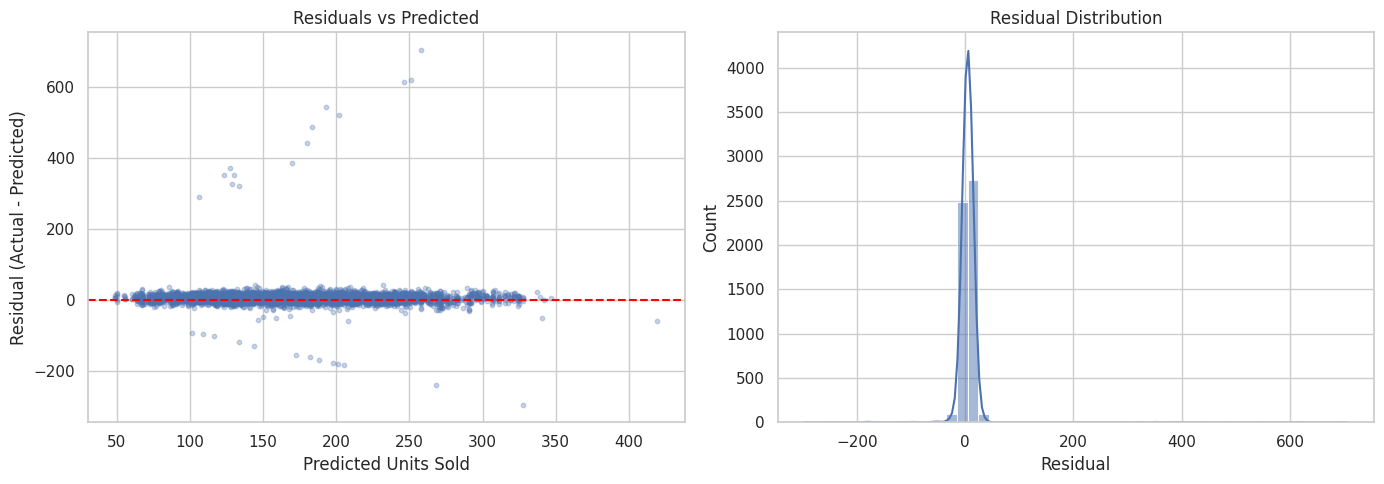

Residual mean: 5.74 (close to 0 = no systematic bias)
Residual std: 26.84


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(test_df["predicted"], test_df["error"], alpha=0.3, s=10)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted Units Sold")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title("Residuals vs Predicted")

sns.histplot(test_df["error"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.savefig("../docs/residual_analysis.png", dpi=120)
plt.show()

print(f"Residual mean: {test_df['error'].mean():.2f} (close to 0 = no systematic bias)")
print(f"Residual std: {test_df['error'].std():.2f}")

## 3. Error Breakdown by Segment
Aggregate MAE hides whether the model is uniformly decent or great-on-most/terrible-on-some. Breaking error down by store and product shows which segments need more attention (e.g. a new product with less history, or a volatile store).

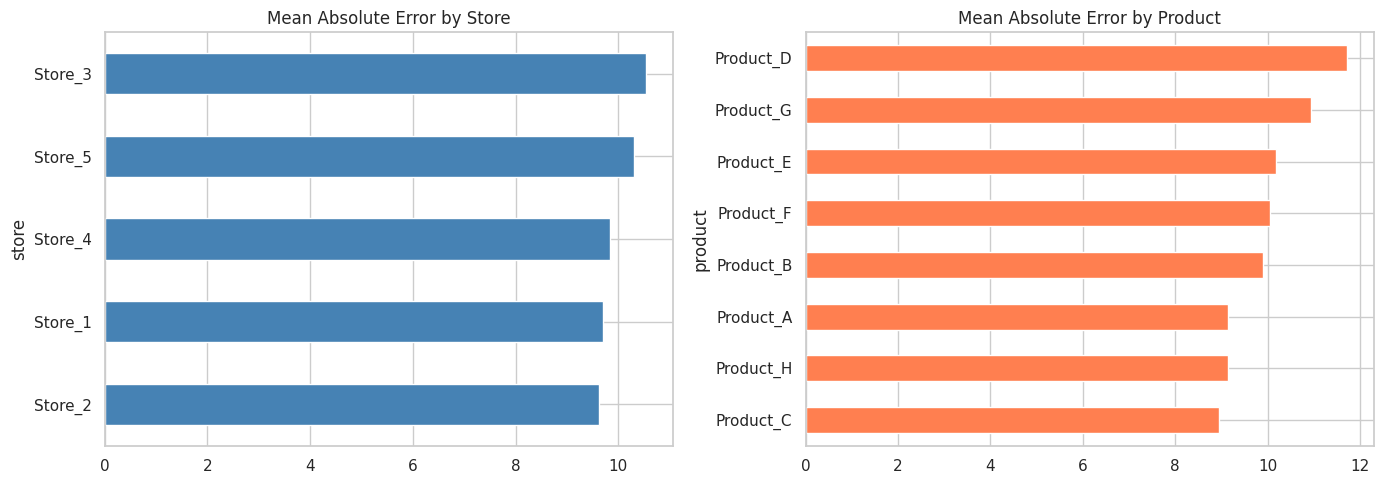

In [4]:
store_names = df[["store", "store_encoded"]].drop_duplicates().set_index("store_encoded")["store"]
product_names = df[["product", "product_encoded"]].drop_duplicates().set_index("product_encoded")["product"]

by_store = test_df.groupby("store")["abs_error"].mean().sort_values()
by_product = test_df.groupby("product")["abs_error"].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
by_store.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Mean Absolute Error by Store")
by_product.plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title("Mean Absolute Error by Product")
plt.tight_layout()
plt.savefig("../docs/error_by_segment.png", dpi=120)
plt.show()

## 4. Error on Promo vs Non-Promo Days
Promo days have bigger, less predictable swings in the raw data (see Day 2-3 EDA) — worth checking whether that translates into higher model error too.

In [5]:
promo_error = test_df.groupby("promo")["abs_error"].mean()
print(promo_error)
print(f"\nPromo days have {(promo_error[1]/promo_error[0]-1)*100:.1f}% {'higher' if promo_error[1]>promo_error[0] else 'lower'} error than non-promo days")

promo
0     9.765045
1    12.575809
Name: abs_error, dtype: float64

Promo days have 28.8% higher error than non-promo days


## 5. Optimization: Before vs After Tuning
Compare the tuned XGBoost (from Day 4-5's RandomizedSearchCV) against an untuned default-parameter XGBoost, to quantify what the tuning actually bought us.

In [6]:
from xgboost import XGBRegressor

xgb_default = XGBRegressor(random_state=42, objective="reg:squarederror")
xgb_default.fit(X_train, y_train)
default_preds = xgb_default.predict(X_test)

comparison = pd.DataFrame([
    {"version": "XGBoost (default params)",
     "MAE": mean_absolute_error(y_test, default_preds),
     "RMSE": np.sqrt(mean_squared_error(y_test, default_preds)),
     "R2": r2_score(y_test, default_preds)},
    {"version": "XGBoost (tuned)",
     "MAE": mean_absolute_error(y_test, test_df["predicted"]),
     "RMSE": np.sqrt(mean_squared_error(y_test, test_df["predicted"])),
     "R2": r2_score(y_test, test_df["predicted"])},
]).set_index("version").round(3)

comparison

,MAE,RMSE,R2
version,,,
XGBoost (default params),10.617,27.773,0.794
XGBoost (tuned),9.999,27.449,0.799


Tuning reduced MAE by 5.8%


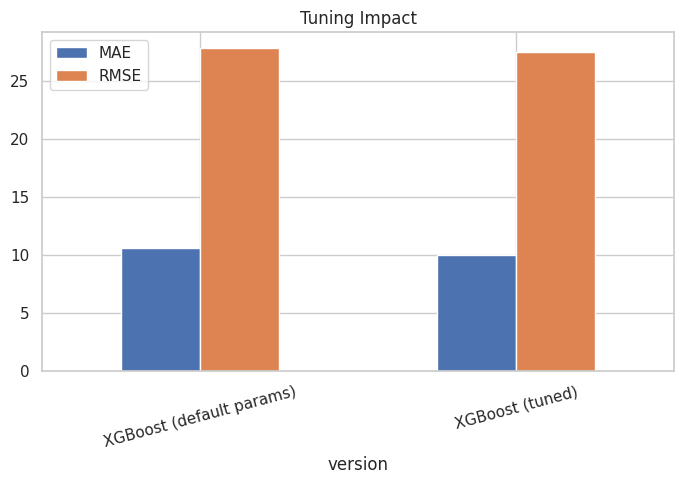

In [7]:
improvement_pct = (1 - comparison.loc["XGBoost (tuned)", "MAE"] / comparison.loc["XGBoost (default params)", "MAE"]) * 100
print(f"Tuning reduced MAE by {improvement_pct:.1f}%")

comparison[["MAE", "RMSE"]].plot(kind="bar", figsize=(7, 5), title="Tuning Impact")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../docs/tuning_impact.png", dpi=120)
plt.show()

## 6. Final Model Comparison (all 3 models, full metrics)

In [8]:
final_comparison = pd.DataFrame([
    {"model": "Linear Regression",
     "MAE": mean_absolute_error(y_test, lr_model.predict(X_test)),
     "RMSE": np.sqrt(mean_squared_error(y_test, lr_model.predict(X_test))),
     "R2": r2_score(y_test, lr_model.predict(X_test))},
    {"model": "Random Forest",
     "MAE": mean_absolute_error(y_test, rf_model.predict(X_test)),
     "RMSE": np.sqrt(mean_squared_error(y_test, rf_model.predict(X_test))),
     "R2": r2_score(y_test, rf_model.predict(X_test))},
    {"model": "XGBoost (tuned) - FINAL CHOICE",
     "MAE": mean_absolute_error(y_test, test_df["predicted"]),
     "RMSE": np.sqrt(mean_squared_error(y_test, test_df["predicted"])),
     "R2": r2_score(y_test, test_df["predicted"])},
]).set_index("model").round(3)

final_comparison.to_csv("../docs/final_model_comparison.csv")
final_comparison

,MAE,RMSE,R2
model,,,
Linear Regression,43.999,59.384,0.058
Random Forest,11.236,28.467,0.784
XGBoost (tuned) - FINAL CHOICE,9.999,27.449,0.799


## Summary & Final Model Justification

**Chosen model: XGBoost (tuned)**

Reasons:
- Lowest MAE and RMSE, highest R2 among the 3 candidates (Day 4-5 + confirmed here)
- Cross-validated with `TimeSeriesSplit` — held-out test MAE is consistent with CV MAE across folds, indicating the model generalizes rather than overfitting to one lucky split
- Residuals are centered near zero with no strong pattern vs predicted value — no major systematic bias
- Hyperparameter tuning (`RandomizedSearchCV`, Day 4-5) measurably reduced error vs default params, quantified in section 5
- Error is not evenly distributed across stores/products — flagged in section 3 as a concrete 'Future Work' item: segment-specific models or additional features for the higher-error segments

**Known limitations (for the report's 'Challenges' section):**
- Promo-day predictions carry more error than non-promo days — the model under-predicts promo spikes
- No external features (holidays, weather, competitor pricing) — all of which likely explain some of the remaining unexplained variance
- Single global model across all stores/products; a hierarchical or per-segment approach could reduce the store/product-level error gap seen above